In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import logsumexp
from scipy.stats import invgamma

# Exercise 1: Adaptive Metropolis-Hastings within Gibbs sampler

## 1.A – Metropolis-Hastings within a Random Scan Gibbs sampler

### 1.

It is a Gibbs sampler because it updates coordinates one at a time, conditionnaly on the other. It is called **Random Scan** Gibbs sampler because at each step, it will update either the first coordinate or the second coordinate at random.

Metropolis-Hastings is used in order to sample from $P_1$ and $P_2$, as we detail in the next question.

### 2.

For $y$ fixed, the target distribution $\pi_1(x)$ is
$$\pi_1(x)\propto \exp\left(\left(\frac{y^2}2-1\right)\frac{x^2}{a^2}-\frac{x^4}{4a^4}\right)$$
Thus, the resulting HM step to sample from $P_1((x,y),\cdot)$ following a symmetric random walk proposal mechanism with a Gaussian distribution with variance $\sigma_1^2$ is:

1. Sample $x^*\sim \mathcal N(x, \sigma_1^2)$
2. Sample $u\sim \mathcal U([0,1])$
3. Calculate the acceptance ratio:
    $$\alpha= \min\left(1, \frac{\pi_1(x^*)}{\pi_1(x)} \right)$$
4. If $u\le \alpha$, return $(x^*,y)$
5. Else, return $(x,y)$.

In [2]:
def sample_from_P1(z, sigma_1, a):
  '''Performs a Metropolis-Hastings step to sample from P1.'''
  x, y = z

  pi_1 = lambda x: np.exp((y**2/2-1)*x**2/a**2 - x**4/(4*a**4))

  x_proposal = np.random.normal(loc=x, scale=sigma_1)
  u = np.random.uniform(low=0, high=1)

  alpha = min(1, pi_1(x_proposal)/pi_1(x))

  if u <= alpha:
    return x_proposal, y
  else:
    return x, y

The algorithm to sample from $P_2$ is similar, but with the target distribution
$$\pi_2(y)\propto \exp\left(\left(\frac{x^2}{2a^2}-1\right)y^2-\frac 1 4 y^4\right)$$

In [3]:
def sample_from_P2(z, sigma_2, a):
  '''Performs a Metropolis-Hastings step to sample from P2.'''
  x, y = z

  pi_2 = lambda y: np.exp((x**2/2/a**2-1)*y**2 - y**4/4)

  y_proposal = np.random.normal(loc=y, scale=sigma_2)
  u = np.random.uniform(low=0, high=1)

  alpha = min(1, pi_2(y_proposal)/pi_2(y))

  if u <= alpha:
    return x, y_proposal
  else:
    return x, y

We finally combine $P_1$ and $P_2$ by sampling from one of them with probability $1/2$, and repeat $N$ times to obtain a Markov chain with kernel $P$

In [4]:
def sample_chain_with_kernel_P(z0, N, sigma_1, sigma_2, a):
  '''Returns a Markov chain with kernel P, of length N and starting in z0.'''

  chain = np.zeros((N+1, 2))
  chain[0] = z0

  for i in range(N):
    z = chain[i]

    # Sample from P
    u = np.random.uniform(low=0, high=1)
    if u <= 1/2:
      z = sample_from_P1(z, sigma_1, a)
    else:
      z = sample_from_P2(z, sigma_2, a)

    chain[i+1] = z

  return chain

### 3.

In [5]:
z0 = (0, 0)
N = 2000
sigma = (3, 3)
a = 10

iterates = sample_chain_with_kernel_P(z0, N, sigma[0], sigma[1], a)

We first plot the $N$ samples generated by the algorithm and compare them with the target distribution $\pi$.

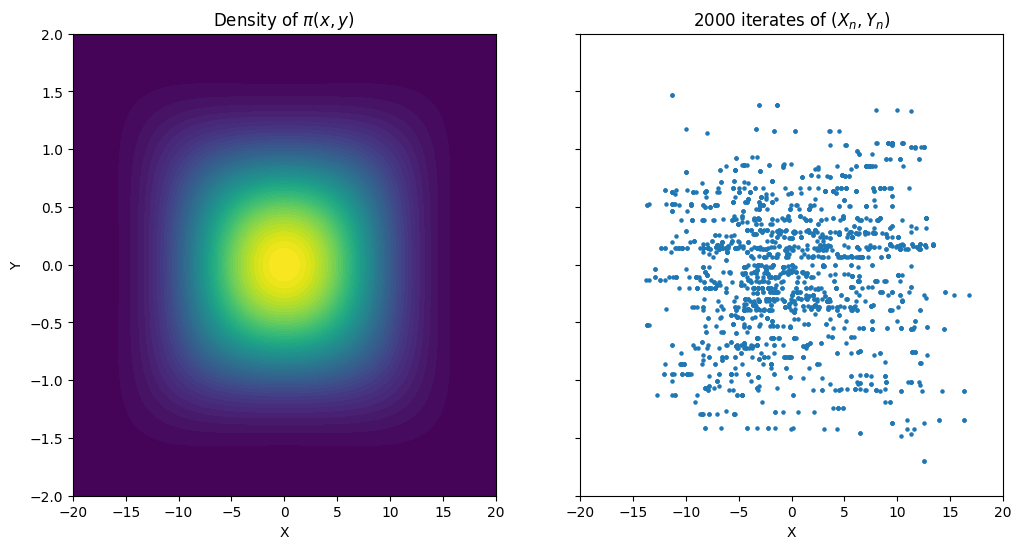

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

x_lim = (-20, 20)
y_lim = (-2, 2)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 100)
y_vals = np.linspace(y_lim[0], y_lim[1], 100)
X, Y = np.meshgrid(x_vals, y_vals)
f = lambda x, y: np.exp(- x**2/a**2 - y**2 - 1/4*(x**2/a**2 - y**2)**2)
Z = f(X, Y)
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $\\pi(x,y)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
axs[1].scatter(iterates[:,0], iterates[:,1], s=5, marker='o')
axs[1].set_title(f'{N} iterates of $(X_n,Y_n)$')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

The distribution of our Markov chain does not seem to be too different from the target distribution. However, we observe horizontal stripes. This means that $X^{(n)}$ moves with steps that are too small, and more frequently than $Y^{(n)}$.

We then plot the auto-correlation between the samples. This measures how independent are the firt samples w.r.t the last ones. For a well-mixed HM, you would expect that the auto-correlation witll decrease quickly so that the chain does not depend too long on its initial value.

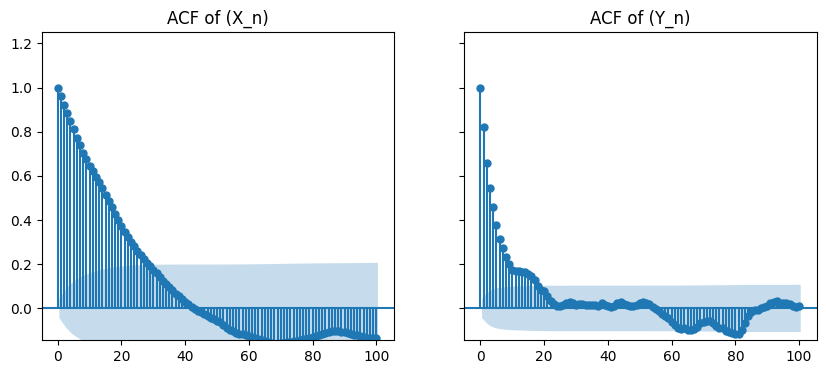

In [7]:
lags = 100

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

plot_acf(iterates[:,0], lags=lags, ax=axs[0], auto_ylims=True, title='ACF of (X_n)')
plot_acf(iterates[:,1], lags=lags, ax=axs[1], auto_ylims=True, title='ACF of (Y_n)')
plt.show()

We observe that for the samples $X$, the autocorrelation decays slowly towards zero. This is a sign of high dependence between samples and poor performance.

Finally, we modify the implementation in order to return the average acceptance rate for $x$ and for $y$.

In [8]:
x, y = z0
acceptance_ratios_x = []
acceptance_ratios_y = []

for i in range(N):
  u = np.random.uniform(low=0, high=1)
  if u <= 1/2:
    pi_1 = lambda x: np.exp((y**2/2-1)*x**2/a**2 - x**4/(4*a**4))
    x_proposal = np.random.normal(loc=x, scale=sigma[0])
    u = np.random.uniform(low=0, high=1)
    alpha = min(1, pi_1(x_proposal)/pi_1(x))
    if np.random.uniform(low=0, high=1) <= alpha:
      x = x_proposal
    acceptance_ratios_x.append(alpha)
  else:
    pi_2 = lambda y: np.exp((x**2/2/a**2-1)*y**2 - y**4/4)
    y_proposal = np.random.normal(loc=y, scale=sigma[1])
    alpha = min(1, pi_2(y_proposal)/pi_2(y))
    if np.random.uniform(low=0, high=1) <= alpha:
      y = y_proposal
    acceptance_ratios_y.append(alpha)

average_acceptance_ratio_x = np.mean(np.array(acceptance_ratios_x))
average_acceptance_ratio_y = np.mean(np.array(acceptance_ratios_y))

print(f'Average acceptance ratio for x: {average_acceptance_ratio_x:.3f}')
print(f'Average acceptance ratio for y: {average_acceptance_ratio_y:.3f}')

Average acceptance ratio for x: 0.849
Average acceptance ratio for y: 0.249


The average acceptance ratio for $y$ is good (around 25-30%). However, for $x$, it is around 85%. This is too high. The proposal distribution is too narrow. This is explained by the fact that $\sigma_1$ and $\sigma_2$ while the target distribution is not isotropic. The chain accepts most proposed moves but only takes very small steps. While the chain is moving, it explores the state space too slowly, leading to the high autocorrelation, as well as the horizontal stripes that appear when plotting the iterates of $(X_n,Y_n)$.

### 4.

Based on the analysis we have made in question 2., one way to improve the performance of the above algorithm would be to increase $\sigma_1$, so that the average acceptation ratio falls down to about 25%.

## 1.B – Adaptive Metropolis-Hastings within Gibbs sampler

### 1.

We first implement the MHwG step for a target distribution $\pi:\mathbb R^d\to\mathbb R^+$ and standard deviations $(\sigma_i)_i$.

In [9]:
def MHwG_step(pi, x, sigmas):
  '''Perform 1 step of the Metropolis-Hastings within Gibbs sampler.
  x is the current state. It should be an array of size d.
  pi is the potentially unnormalized density. It should be a function from R^d to R+.
  sigmas is the array of standard deviations of the proposal for each dimension.
  Return the new value of x, and the acceptance rates for each coordinate'''

  d = len(x)
  current_x = x.copy()
  alphas = np.zeros(d)

  for i in range(d):
    proposed_x = current_x.copy()
    proposed_x[i] = np.random.normal(loc=current_x[i], scale=sigmas[i])
    alphas[i] = min(1, pi(proposed_x)/pi(current_x))
    u = np.random.uniform(low=0, high=1)
    if u <= alphas[i]:
      current_x = proposed_x

  return current_x, alphas

In [10]:
def adaptative_MHwG(pi, x0, N):
  '''Run N steps of the adaptive Metropolis-Hastings within Gibbs
  sampler, starting in x0.'''

  BATCH_SIZE = 50
  OPTIMAL_RATE = 0.234

  d = len(x0)
  l = np.zeros(d)
  cum_alphas = np.zeros(d)

  iterates = np.zeros((N+1, d))
  iterates[0] = x0

  for j in range(N):
    # Regular step
    x = iterates[j]
    sigmas = np.exp(l)
    x, alphas = MHwG_step(pi, x, sigmas)
    iterates[j+1] = x
    cum_alphas += alphas

    if (j+1) % BATCH_SIZE == 0:
      # Update of l
      delta = min(0.05, j**(-1/2))
      for i in range(d):
        if cum_alphas[i]/50 > OPTIMAL_RATE:
          l[i] += delta
        else:
          l[i] -= delta
      cum_alphas = np.zeros(d) # Reset the cumulated acceptance rate

  return iterates

In [11]:
a = 10
pi = lambda x: np.exp(-x[0]**2/a**2 - x[1]**2 - 1/4*(x[0]**2/a**2-x[1]**2)**2)
x0 = np.array([0, 0])
N = 10000
iterates = adaptative_MHwG(pi, x0, N)

We plot the ACF of the iterates obtained by Adaptive MHwG, and compare them with iterates obtained with previous implementation.

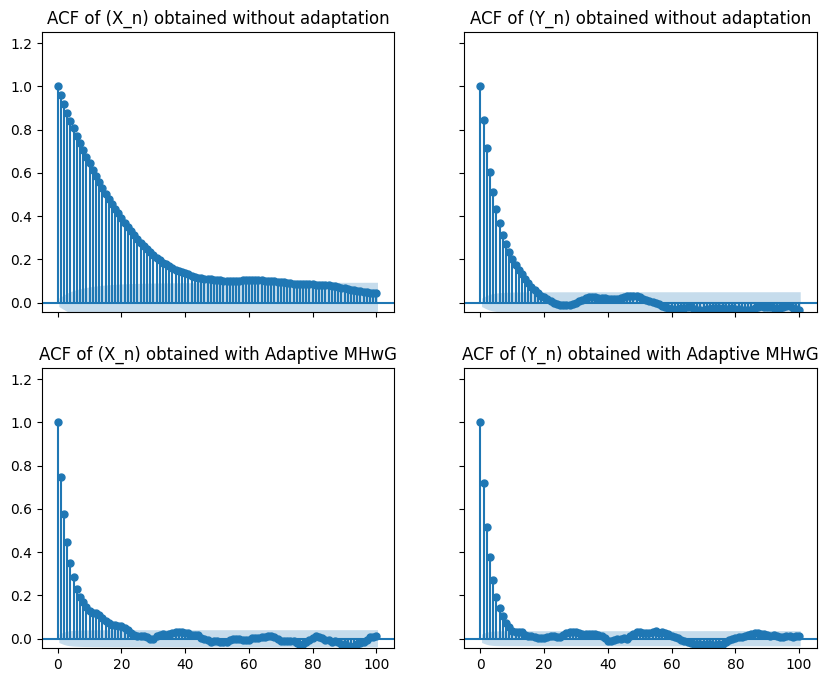

In [12]:
lags = 100

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

iterates_without_adaptation = sample_chain_with_kernel_P((0, 0), N, 3, 3, a)

plot_acf(iterates_without_adaptation[:,0], lags=lags, ax=axs[0,0], auto_ylims=True, title='ACF of (X_n) obtained without adaptation')
plot_acf(iterates_without_adaptation[:,1], lags=lags, ax=axs[0,1], auto_ylims=True, title='ACF of (Y_n) obtained without adaptation')

plot_acf(iterates[:,0], lags=lags, ax=axs[1,0], auto_ylims=True, title='ACF of (X_n) obtained with Adaptive MHwG')
plot_acf(iterates[:,1], lags=lags, ax=axs[1,1], auto_ylims=True, title='ACF of (Y_n) obtained with Adaptive MHwG')

plt.show()

With adaptation, the autocorrelations decrease way faster towards zero, especially for the first dimension. This is a sign of good mixing. The performance of the algorithm is better with adaptation.

### 2.

In [13]:
d = 5
B = 0.4
f_B = lambda x: np.exp(-x[0]**2/2 - 1/2*(x[1]+B*x[0]**2-B)**2 - 1/2*np.sum(np.square(x[2:d])))

In [14]:
N = 10000
iterates = adaptative_MHwG(f_B, np.zeros(d), N)

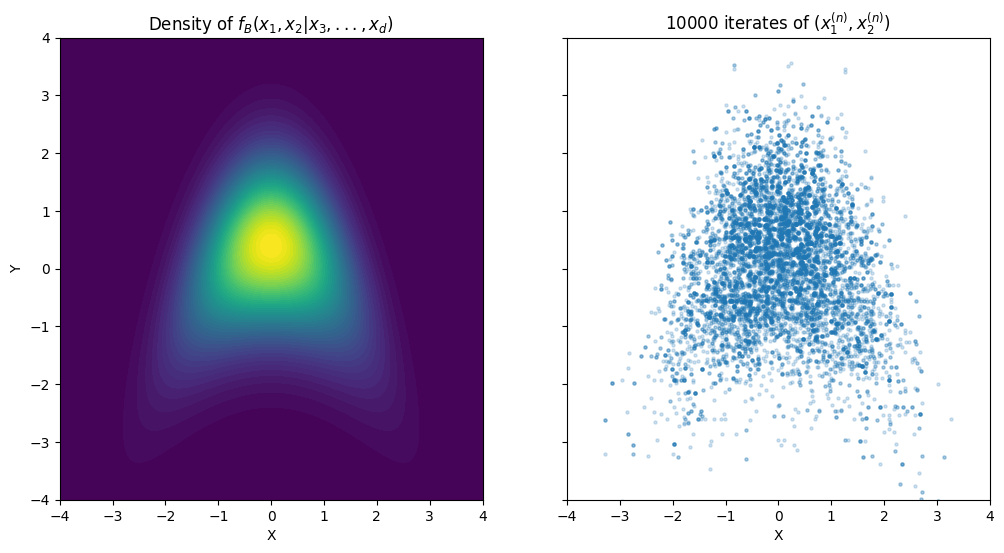

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

x_lim = (-4, 4)
y_lim = (-4, 4)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 1000)
y_vals = np.linspace(y_lim[0], y_lim[1], 1000)
X, Y = np.meshgrid(x_vals, y_vals)
f = lambda x, y: np.exp(-x**2/2 - 1/2*(y+B*x**2-B)**2)
Z = f(X, Y)
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $f_B(x_1,x_2|x_3,...,x_d)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
axs[1].scatter(iterates[:,0], iterates[:,1], s=5, marker='o', alpha=0.2)
axs[1].set_title(str(N) + ' iterates of $(x_1^{(n)},x_2^{(n)})$')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

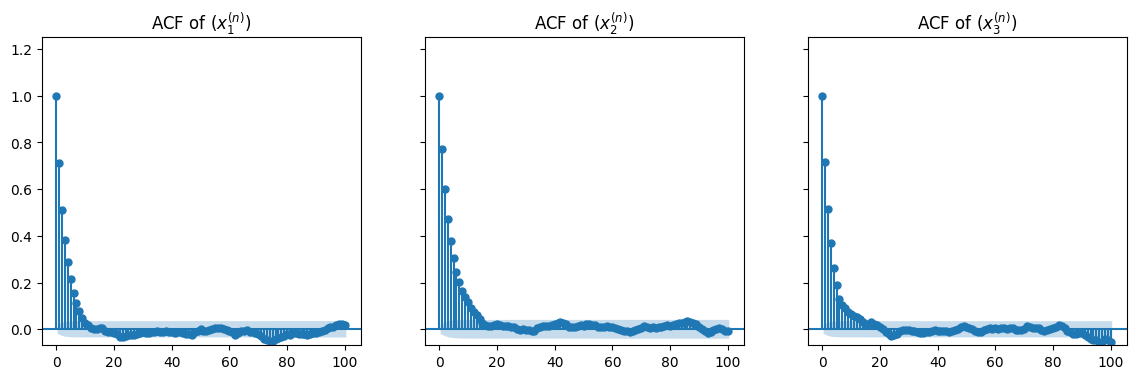

In [16]:
lags = 100

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

plot_acf(iterates[:,0], lags=lags, ax=axs[0], auto_ylims=True, title='ACF of $(x_1^{(n)})$')
plot_acf(iterates[:,1], lags=lags, ax=axs[1], auto_ylims=True, title='ACF of $(x_2^{(n)})$')
plot_acf(iterates[:,2], lags=lags, ax=axs[2], auto_ylims=True, title='ACF of $(x_3^{(n)})$')
plt.show()

# Exercise 2: Sampling from multimodal distributions

## 2.A – A toy example

### 1.

In [17]:
MUS = np.array([
  [2.18, 5.76],
  [8.67, 9.59],
  [4.24, 8.48],
  [8.41, 1.68],
  [3.93, 8.82],
  [3.25, 3.47],
  [1.70, 0.50],
  [4.59, 5.60],
  [6.91, 5.81],
  [6.87, 5.40],
  [5.41, 2.65],
  [2.70, 7.88],
  [4.98, 3.70],
  [1.14, 2.39],
  [8.33, 9.50],
  [4.93, 1.50],
  [1.83, 0.09],
  [2.26, 0.31],
  [5.54, 6.86],
  [1.69, 8.11]
])
w = 0.05
sigma = 0.1

In [18]:
def pi(x):
  '''Compute pi. This function is vectorized
  so that it accepts arrays of shape (2), (n, 2) and (n, n, 2).'''

  # Calculate the squared difference between x and each mean (MUS)
  diff_squared = np.square(x[..., np.newaxis, :] - MUS) # shape = (..., 20, 2)

  # Sum the squared differences over the last axis to get squared Euclidean distance
  sum_diff_squared = np.sum(diff_squared, axis=-1) # shape = (..., 20)

  # Calculate the Gaussian term
  gaussian_term = np.exp(-1 / (2 * sigma**2) * sum_diff_squared)

  # Calculate the pre-factor for each Gaussian component
  pre_factor = w / (2 * np.pi * sigma**2)

  # Sum over all Gaussian components. shape = (...,)
  return np.sum(pre_factor * gaussian_term, axis=-1)

For $\log\pi$, we use logsumexp to avoid numerical instability

In [19]:
def logpi(x):
  diff_squared = np.square(x[..., np.newaxis, :] - MUS)
  sum_diff_squared = np.sum(diff_squared, axis=-1)

  # Compute the total log density of each Gaussian
  log_density = - np.log(2 * np.pi * sigma**2) - sum_diff_squared / (2 * sigma**2)

  return logsumexp(np.log(w) + log_density, axis=-1)

### 2.

We implement the classical Metropolis-Hastings with Symmetric Random Walk

In [20]:
def MH_SRW(pi, x0, N, sigma):
  '''Run N steps of the Metropolis-Hastings Symmetric Random Walk, with isotropic
  Gaussian proposal of variance sigma,
  starting in x0.'''
  d = len(x0)
  iterates = np.zeros((N+1, d))
  iterates[0] = x0
  for i in range(N):
    x = iterates[i]
    x_proposal = x + np.random.normal(loc=0, scale=sigma, size=(d,))
    alpha = min(1, pi(x_proposal)/pi(x))
    u = np.random.uniform(low=0, high=1)
    if u <= alpha:
      iterates[i+1] = x_proposal
    else:
      iterates[i+1] = x

  return iterates

### 3.

Let us first plot the density of $\pi$ and the values taken by the Markov Chain generated by the classical MH Symmetric Random Walk, for several values of $x^{(0)}$.

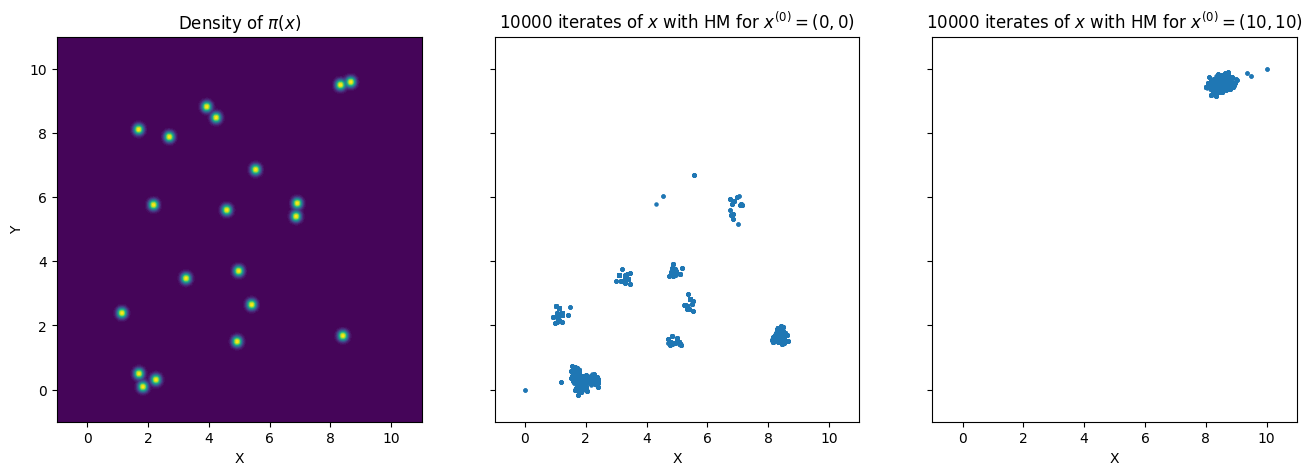

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

x_lim = (-1, 11)
y_lim = (-1, 11)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 1000)
y_vals = np.linspace(y_lim[0], y_lim[1], 1000)
X, Y = np.meshgrid(x_vals, y_vals)
Z = pi(np.stack((X, Y), axis=-1))
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $\\pi(x)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
x0 = np.array([0, 0])
N = 10000
iterates = MH_SRW(pi, x0, N, sigma=1)

axs[1].scatter(iterates[:,0], iterates[:,1], s=5, marker='o',)
axs[1].set_title(str(N) + ' iterates of $x$ with HM for $x^{(0)}=(0,0)$')

x0 = np.array([10, 10])
N = 10000
iterates = MH_SRW(pi, x0, N, sigma=1)

axs[2].scatter(iterates[:,0], iterates[:,1], s=5, marker='o',)
axs[2].set_title(str(N) + ' iterates of $x$ with HM for $x^{(0)}=(10,10)$')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
axs[2].set_xlabel('X')

plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

We see that the Markov chain visits some modes, but not all of them. This is because the proposal struggles to jump between distant modes. Also, the resulting distribution highly depends on the initial $x^{(0)}$. The chain effectively gets stuck in few modes and cannot explore the full target distribution. Thus, the MH algorithm fails to sample from $\pi$.

Let us see the results with the adaptative MHwG algorithm.

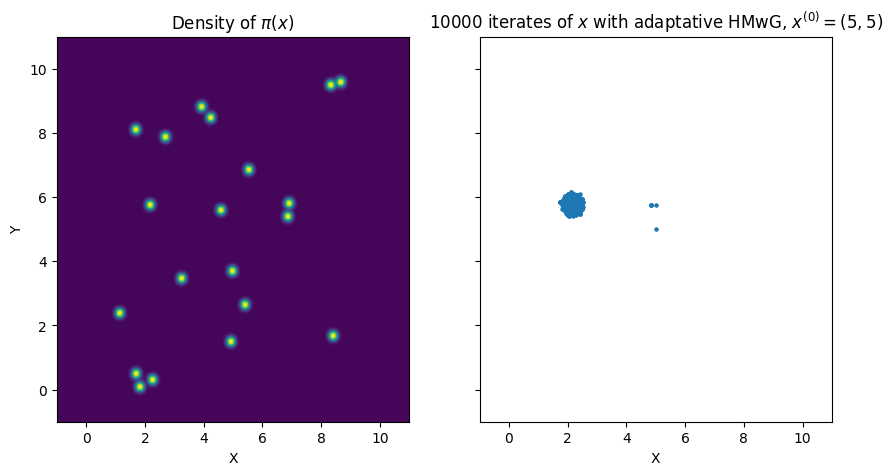

In [22]:
x0 = np.array([5, 5])
N = 10000
iterates = adaptative_MHwG(pi, x0, N)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

x_lim = (-1, 11)
y_lim = (-1, 11)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 1000)
y_vals = np.linspace(y_lim[0], y_lim[1], 1000)
X, Y = np.meshgrid(x_vals, y_vals)
Z = pi(np.stack((X, Y), axis=-1))
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $\\pi(x)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
axs[1].scatter(iterates[:,0], iterates[:,1], s=5, marker='o',)
axs[1].set_title(str(N) + ' iterates of $x$ with adaptative HMwG, $x^{(0)}=(5,5)$')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

Results are similar, adaptative HMwG fails to sample from $\pi$.

## 2.B – Parallel Tempering

### 1.

The distribution $\pi^{1/T_1}$ will no longer have these large zero-probability zones between the modes that avoid to sample efficently from it. We confirm that by plotting its density for the values of $T$ given in question 3.

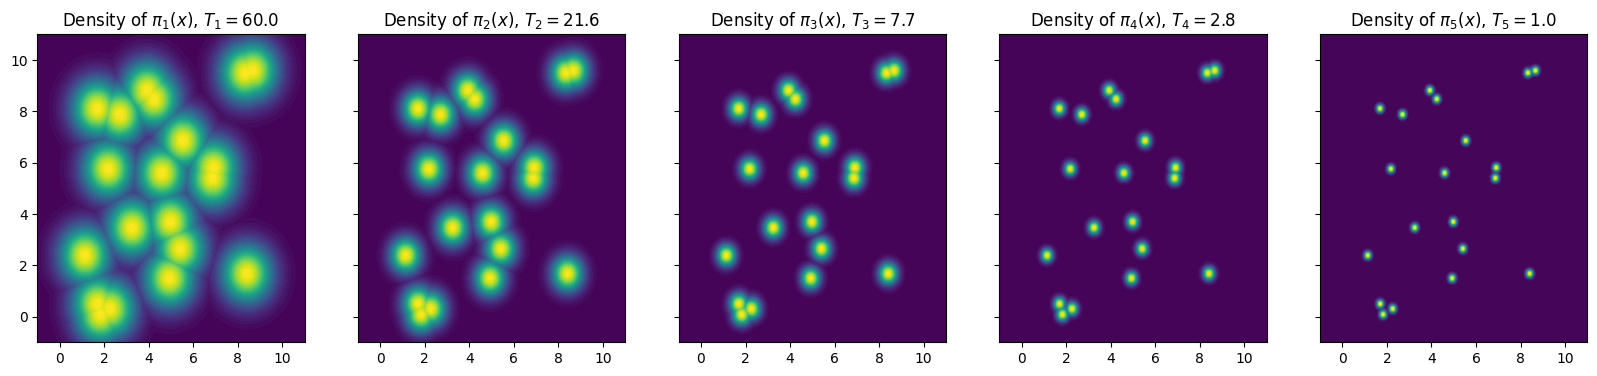

In [23]:
T = np.array([60., 21.6, 7.7, 2.8, 1.])

fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

x_lim = (-1, 11)
y_lim = (-1, 11)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 500)
y_vals = np.linspace(y_lim[0], y_lim[1], 500)
X, Y = np.meshgrid(x_vals, y_vals)
Z = pi(np.stack((X, Y), axis=-1))

for i in range(5):
  axs[i].contourf(X, Y, Z**(1/T[i]), levels=50, cmap='viridis')
  axs[i].set_title(f'Density of $\\pi_{i+1}(x)$, $T_{i+1}={T[i]}$')

The distribution $\pi_K$ is exactly the target distribution $\pi$ we want to sample from. As $T$ increases, the distribution $\pi_i=\pi^{1/T}$ becomes less "sparse", the modes are less separated by wide valleys of near-zero probability. It was these valleys that prevented the Markov chain from jumping between distant modes. Thus, for large temperatures, the Markov chains will easily visit all the modes, and thanks to the swapping, $X^{(K)}$ will also visit all the modes, while matching density $\pi$.

### 2.

In [24]:
def parallel_tempering(pi, x0, N, T):
  '''Run Algorithm 2 for N iterations.
  Requires the density pi, an initial value x0, a number of iterations N,
  and the array of temperatures T.'''
  d = len(x0)
  K = len(T)

  tau = 0.25 * np.sqrt(T)

  X = np.zeros((N+1, K, d)) # X contains all iterates at each time, for each temperature

  # -- 1.Initialize X0
  for i in range(K):
    X[0, i] = x0

  for n in range(N):

    # -- 3. For all i, draw Y^i
    Y = np.zeros((K, d))
    for i in range(K):
      # Sample proposal distribution from an isotropic Gaussian distribution of scale tau
      Y[i] = X[n, i] + np.random.normal(scale=tau[i], size=(d))
      # Compute acceptance rate
      alpha = min(1, pi(Y[i])**(1/T[i]) / pi(X[n, i])**(1/T[i]))
      # Accept or reject
      if np.random.random() > alpha:
        Y[i] = X[n, i]

    # -- 4. Choose uniformly i, j from {(i,j): 0<=i,j<K, |i-j|=1}
    if np.random.random() < 1/2: # i=j+1
      j = np.random.randint(0, K-1)
      i = j+1
    else: # i=j-1
      i = np.random.randint(0, K-1)
      j = i+1

    # -- 5. Compute the swap acceptance rate
    alpha = min(1, pi(Y[j])**(1/T[i]) * pi(Y[i])**(1/T[j]) / (pi(Y[i])**(1/T[i]) * pi(Y[j])**(1/T[j])))

    # First, fill the k \ne i,j rows
    X[n+1] = Y

    # -- 6 to 10. Do the swap with probability alpha
    U = np.random.random()
    if U <= alpha:
      X[n+1, i] = Y[j]
      X[n+1, j] = Y[i]
    # If u>alpha, we do not have to do anything.

  return X

### 3.

In [25]:
N = 10000
iterates = parallel_tempering(pi, np.array([5, 5]), N, T)

We now visualize the values taken by $X^{(K)}$.

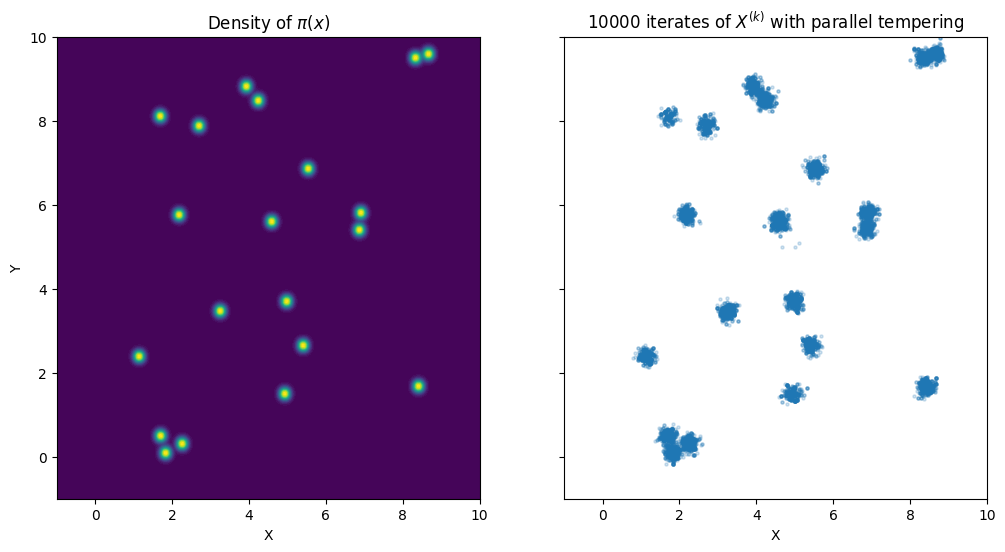

In [26]:
T = np.array([60., 21.6, 7.7, 2.8, 1.])

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

x_lim = (-1, 10)
y_lim = (-1, 10)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 1000)
y_vals = np.linspace(y_lim[0], y_lim[1], 1000)
X, Y = np.meshgrid(x_vals, y_vals)
Z = pi(np.stack((X, Y), axis=-1))
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $\\pi(x)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
axs[1].scatter(iterates[:,4,0], iterates[:,4,1], s=5, marker='o', alpha=0.2)
axs[1].set_title(str(N) + ' iterates of $X^{(k)}$ with parallel tempering')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

HM with parallel tempering achieves to sample from every mode of the target distribution $\pi$.

# Exercise 3: Bayesian analysis of a one-way random effects model

### 1.

We have
$$p(Y,X,\mu,\sigma^2,\tau^2)=p(Y|X,\mu,\sigma^2,\tau^2)\, p(X|\mu,\sigma^2,\tau^2)\,\pi_{prior}(\mu,\sigma^2,\tau^2)$$
Let's develop each factor.

$$p(Y|X,\mu,\sigma^2,\tau^2)=\prod_{i=1}^N \prod_{j=1}^{k_i} p(Y_{i,j}|X_i, \tau^2)$$
For all $i,j$, $Y_{i,j}-X_i\sim^{i.i.d} \mathcal N(0,\tau^2)$, thus
$$p(Y|X,\mu,\sigma^2,\tau^2)=\prod_{i=1}^N \prod_{j=1}^{k_i} \mathcal N (Y_{i,j}-X_i;0,\tau^2)=\prod_{i=1}^N \prod_{j=1}^{k_i} \frac{1}{\sqrt{2\pi\tau^2}} \exp\left( - \frac{(Y_{i,j}-X_i)^2}{2\tau^2}\right)$$
Thus, the log-likelihood is
$$\log p(Y|X,\mu,\sigma^2,\tau^2) = -k \log \tau- \frac{1}{2\tau^2} \sum_{i,j}(Y_{i,j}-X_i)^2+\text{const}$$

$$p(X|\mu,\sigma^2\tau^2)= \prod_{i=1}^N \mathcal N(X_i;\mu, \sigma^2)$$
The log-likelihood is
$$\log p(X|\mu,\sigma^2\tau^2) = -N \log \sigma - \frac{1}{2\sigma^2} \sum_{i=1}^N (X_i-\mu)^2+\text{const}$$

Combining this with the prior $\pi_{prior}(\mu,\sigma^2,\tau^2)$ we obtain the total log-density $\log p(Y,X,\mu,\sigma^2,\tau^2)$.

Finally, by Bayes' Theorem,
$$\log p(X,\mu,\sigma^2,\tau|Y)=\log p (Y,X,\mu,\sigma^2,\tau^2)+\text{const}$$
so
$$\log p(X,\mu,\sigma^2,\tau|Y) = -(k+2(1+\gamma)) \log \tau- \frac{1}{2\tau^2} \sum_{i,j}(Y_{i,j}-X_i)^2-(N+2(1+\alpha)) \log \sigma - \frac{1}{2\sigma^2} \sum_{i=1}^N (X_i-\mu)^2-\frac{\beta}{\sigma^2}-\frac{\beta}{\tau^2}+\text{const}$$

### 2.

Let us first determine the density of each element of $(\sigma^2, \tau^2, \mu, X)$ conditionnaly on the others, using the density we have determined in question 1.

* $\sigma^2$

$$\pi(\sigma^2|\tau^2,\mu,X,Y) \propto \frac{1}{(\sigma^2)^{N/2+\alpha+1}} \exp\left(-\frac 1 {\sigma^2}\left(\beta+\frac{1}2\sum_{i=1}^N (X_i-\mu)^2\right)\right)$$

Thus, $\sigma^2$ follows an inverse gamma distribution of parameters $(\frac{N}2+\alpha, \beta+\frac{1}2\sum_{i=1}^N (X_i-\mu)^2)$

* $\tau^2$

$$\pi(\tau^2|\sigma^2, \mu, X, Y)\propto \frac{1}{(\tau^2)^{k/2+\gamma+1}} \exp\left(-\frac{1}{\tau^2}\left(\beta + \frac{1}{2}\sum_{i,j}(Y_{i,j}-X_i)^2\right)\right)$$
Thus, $\tau^2$ follows an inverse gamma distribution of parameters $(\frac k2+\gamma,\beta + \frac{1}{2}\sum_{i,j}(Y_{i,j}-X_i)^2)$

* $\mu$
$$\pi(\mu|\sigma^2,\tau^2, X, Y) \propto \exp\left(-\frac{\sum_{i=1}^N (X_i-\mu)^2}{2\sigma^2}\right)$$
We have that
$$\sum_{i=1}^N (X_i-\mu)^2 = N\mu^2 - 2 \mu \sum_{i=1}^N X_i + \sum_{i=1}^N X_i^2 = N\left(\mu-\frac{1}{N}\sum_{i=1}^N X_i\right)^2+\text{const}$$
Thus,
$$\pi(\mu|\sigma^2,\tau^2, X, Y) \propto\exp\left(-\frac{\left(\mu-\frac{1}{N}\sum_{i=1}^N X_i\right)^2}{2 (\sigma/\sqrt N)^2}\right)$$
Hence, $\mu$ follows a Normal distribution of parameters $(\frac{1}{N}\sum_{i=1}^N X_i, \frac{\sigma}{\sqrt N})$

* $X_i$

Let $i\in\{1,...,N\}$. Denote $X_{-i}=(X_1,...,X_{i-1},X_{i+1},...,X_N)$.
$$\pi(X_i|\sigma^2,\tau^2, \mu,X_{-i}) \propto \exp\left(-\frac{\sum_{j=1}^{k_i}(Y_{i,j}-X_i)^2}{2\tau^2}\right)\exp\left(-\frac{(X_i-\mu)^2}{2\sigma^2}\right)$$
We have that
$$\frac{\sum_{j=1}^{k_i}(Y_{i,j}-X_i)^2}{2\tau^2}+\frac{(X_i-\mu)^2}{2\sigma^2} = \frac{1}{2}\left(\frac{k_i}{\tau^2}+\frac{1}{\sigma^2}\right)X_i^2 - \left(\frac{\sum_{j=1}^{k_i}Y_{i,j}}{\tau^2}+\frac{\mu}{\sigma^2}\right)X_i +\text{const}$$
$$\frac{\sum_{j=1}^{k_i}(Y_{i,j}-X_i)^2}{2\tau^2}+\frac{(X_i-\mu)^2}{2\sigma^2} = \frac{(X_i-m_i)^2}{2s_i^2}+\text{const}$$
with
$$s_i^2 = \left(\frac{k_i}{\tau^2}+\frac{1}{\sigma^2}\right)^{-1} = \frac{\sigma^2\tau^2}{k_i\,\sigma^2+\tau^2}$$
and
$$m_i = \left(\frac{\sum_{j=1}^{k_i}Y_{i,j}}{\tau^2}+\frac{\mu}{\sigma^2}\right)s_i^2 = \frac{\sigma^2 \sum_{j=1}^{k_i}Y_{i,j} + \mu\,\tau^2}{k_i\,\sigma^2+\tau^2} $$
Finally, we have
$$\pi(X_i|\sigma^2,\tau^2, \mu,X_{-i}) \propto \exp\left(-\frac{(X_i-m_i)^2}{2s_i^2}\right)$$
Hence, $X_i$ follows a Norla distribution of parameters $(m_i,s_i^2)$.

We can now implement our Gibbs sampler.

In [27]:
def gibbs_sampler(N_ITER, Y, sigma_squared_init, tau_squared_init, mu_init, X_init, alpha, beta, gamma):
  '''Perform N_ITER steps of the Gibbs sampler for the distribution (sigma^2,tau^2,mu,X)
  starting from the initial values (sigma_squared_init, tau_squared_init, mu_init, X_init).
  Also requires the observations Y and the params alpha, beta, gamma'''

  N = len(X_init)
  k = sum([len(Y[i]) for i in range(N)])

  sigma_squared_iterates = np.zeros(N_ITER+1)
  tau_squared_iterates = np.zeros(N_ITER+1)
  mu_iterates = np.zeros(N_ITER+1)
  X_iterates = np.zeros((N_ITER+1, N))

  sigma_squared_iterates[0] = sigma_squared_init
  tau_squared_iterates[0] = tau_squared_init
  mu_iterates[0] = mu_init
  X_iterates[0] = X_init

  for n in range(N_ITER):

    # SAMPLE SIGMA SQUARED
    sigma_squared = invgamma.rvs(
        a = N/2 + alpha,
        scale = beta + 1/2 * np.sum((X_iterates[n] - mu_iterates[n])**2)
    )
    sigma_squared_iterates[n+1] = sigma_squared

    # SAMPLE TAU SQUARED
    tau_squared = invgamma.rvs(
        a = k/2 + gamma,
        scale = beta + 1/2 * sum([np.sum((np.array(Y[i]) - X_iterates[n, i])**2) for i in range(N)])
    )
    tau_squared_iterates[n+1] = tau_squared

    # SAMPLE MU
    mu = np.random.normal(
        loc = np.sum(X_iterates[n]) / N,
        scale = np.sqrt(sigma_squared / N)
    )
    mu_iterates[n+1] = mu

    # SAMPLE X_i's
    for i in range(N):
      s_i_squared = sigma_squared * tau_squared / (len(Y[i]) * sigma_squared + tau_squared)
      m_i = (sigma_squared * np.sum(Y[i]) + mu * tau_squared) / (len(Y[i]) * sigma_squared + tau_squared)
      X_iterates[n+1, i] = np.random.normal(loc=m_i, scale=np.sqrt(s_i_squared))

  return sigma_squared_iterates, tau_squared_iterates, mu_iterates, X_iterates


### 3.

Let us now generate a synthetic dataset $Y$.

In [28]:
alpha = 1
beta = 2
gamma = 3

true_sigma_squared = 0.5
true_tau_squared = 1
true_mu = -1

N = 100

true_X = np.random.normal(loc=true_mu, scale=np.sqrt(true_sigma_squared), size=N)

k_i = 10 # Chose the same k_i for all i for simplicity

Y = true_X[:, None] + np.random.normal(scale=np.sqrt(true_tau_squared), size=(N, k_i))

In [29]:
# Initial values
sigma_squared_init = 2
tau_squared_init = 3
mu_init = 1
X_init = np.random.normal(loc = mu_init, scale = np.sqrt(sigma_squared_init), size=N)

We now run the Gibbs sampler on this dataset

In [30]:
N_ITER = 5000
sigma_squared_iterates, tau_squared_iterates, mu_iterates, X_iterates = gibbs_sampler(N_ITER, Y, sigma_squared_init, tau_squared_init, mu_init,X_init, alpha, beta, gamma)

We now compare the distributions of $(\sigma^2, \tau^2, \mu)$ generated by the Gibbs sampler, and compare them to the true values.

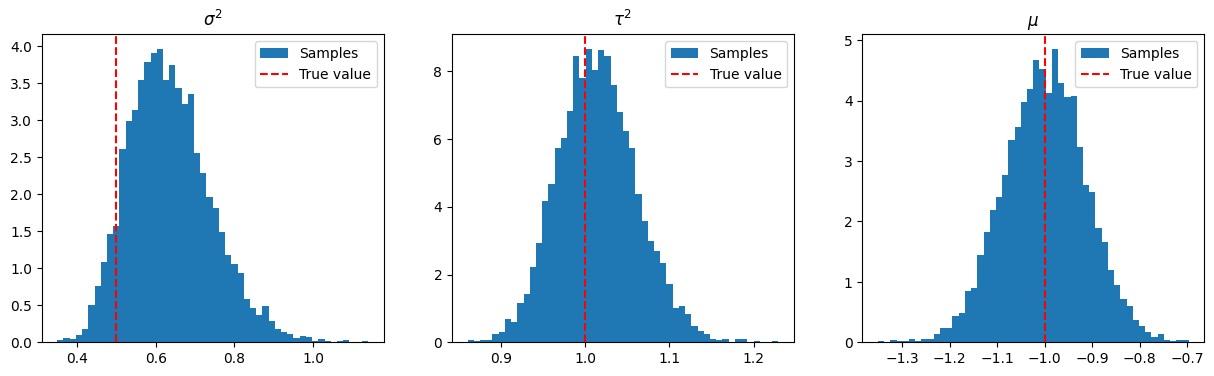

In [31]:
BURNIN = 50

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(sigma_squared_iterates[BURNIN:], bins=50, density=True, label='Samples')
axs[0].axvline(true_sigma_squared, color='r', linestyle='--', label='True value')
axs[0].set_title(r'$\sigma^2$')
axs[0].legend()

axs[1].hist(tau_squared_iterates[BURNIN:], bins=50, density=True, label='Samples')
axs[1].axvline(true_tau_squared, color='r', linestyle='--', label='True value')
axs[1].set_title(r'$\tau^2$')
axs[1].legend()

axs[2].hist(mu_iterates[BURNIN:], bins=50, density=True, label='Samples')
axs[2].axvline(true_mu, color='r', linestyle='--', label='True value')
axs[2].set_title(r'$\mu$')
axs[2].legend()

plt.show()

The Gibbs sampler enables to sample $\mu$, $\sigma^2$ and $\tau^2$ reasonably well.

### 4.

We now need to compute the conditional density
$$\pi(X,\mu|\sigma^2,\tau^2,Y)\,.$$
We have
$$\pi(X,\mu|\sigma^2,\tau^2,Y) \propto \exp\left(-\frac{\sum_{i,j}(Y_{i,j}-X_i)^2}{2\tau^2}\right)\exp\left(-\frac{\sum_{i}(X_i-\mu)^2}{2\sigma^2}\right)$$
Denote
$V = (X_1,...,X_N,\mu)^\top\in\mathbb R^{N+1}$. We then have
$$\sum_{i}(X_i-\mu^2) = V^\top A V$$
with
$$A= \begin{bmatrix} I_N & -\mathbf 1_N \\ -\mathbf 1_N^\top & 1 \end{bmatrix}$$
This allows us to write, after some computations,
$$\pi(X,\mu|\sigma^2,\tau^2,Y) \propto \exp\left(-\frac 1 2 (V-m)^\top \Sigma^{-1}(V-m)\right)$$
with
$$\Sigma^{-1} = \begin{bmatrix} \operatorname{Diag}\left(\frac{1}{\sigma^2}+\frac{k_i}{\tau^2}\right) & -\frac{1}{\sigma^2}\mathbf 1_N \\ -\frac{1}{\sigma^2}\mathbf 1_N^\top & \frac{N}{\sigma^2} \end{bmatrix}$$
and
$$m = \Sigma \,\cdot\, \left( \frac{1}{\tau^2} \sum_{j=1}^{k_1}Y_{1,j},...,\frac{1}{\tau^2} \sum_{j=1}^{k_N}Y_{N,j}, 0\right)^\top$$
Finally, $V$ follows a multivariate Normal distribution with parameters $(\mu, \Sigma)$.

In [32]:
def block_gibbs_sampler(N_ITER, Y, sigma_squared_init, tau_squared_init, mu_init, X_init, alpha, beta, gamma):
  '''Perform N_ITER steps of the Block Gibbs sampler for the distribution (sigma^2,tau^2,mu,X)
  starting from the initial values (sigma_squared_init, tau_squared_init, mu_init, X_init).
  Also requires the observations Y and the params alpha, beta, gamma'''

  N = len(X_init)
  k = sum([len(Y[i]) for i in range(N)])

  sigma_squared_iterates = np.zeros(N_ITER+1)
  tau_squared_iterates = np.zeros(N_ITER+1)
  mu_iterates = np.zeros(N_ITER+1)
  X_iterates = np.zeros((N_ITER+1, N))

  sigma_squared_iterates[0] = sigma_squared_init
  tau_squared_iterates[0] = tau_squared_init
  mu_iterates[0] = mu_init
  X_iterates[0] = X_init

  for n in range(N_ITER):

    # SAMPLE SIGMA SQUARED
    sigma_squared = invgamma.rvs(
        a = N/2 + alpha,
        scale = beta + 1/2 * np.sum((X_iterates[n] - mu_iterates[n])**2)
    )
    sigma_squared_iterates[n+1] = sigma_squared

    # SAMPLE TAU SQUARED
    tau_squared = invgamma.rvs(
        a = k/2 + gamma,
        scale = beta + 1/2 * sum([np.sum((np.array(Y[i]) - X_iterates[n, i])**2) for i in range(N)])
    )
    tau_squared_iterates[n+1] = tau_squared

    # SAMPLE X and MU
    # First compute Sigma and mu
    Sigma_inv = np.zeros((N+1, N+1))
    for i in range(N):
      Sigma_inv[i, i] = 1/sigma_squared + len(Y[i])/tau_squared
      Sigma_inv[i, N] = -1/sigma_squared
      Sigma_inv[N, i] = -1/sigma_squared
    Sigma_inv[N, N] = N/sigma_squared
    Sigma = np.linalg.inv(Sigma_inv)

    m = np.zeros(N+1)
    for i in range(N):
      m[i] = 1/tau_squared * np.sum(Y[i])
    m = Sigma @ m

    # Sample V
    V = np.random.multivariate_normal(mean=m, cov=Sigma)

    mu_iterates[n+1] = V[N]
    X_iterates[n+1] = V[:N]

  return sigma_squared_iterates, tau_squared_iterates, mu_iterates, X_iterates